#### Importing important libraries

In [1]:
import pandas as pd
import numpy as np
from  scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading & Data Parsing

In [2]:
df = pd.read_csv('../data/nigeria.csv')

##### Adding a country column

In [3]:
df["COUNTRY"] = ["NIGERIA"] * len(df)

##### Convert the YEAR and DOY columns into a proper datetime column

In [4]:
df["DATETIME"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

##### Extracting Month into its own column

In [5]:
df["YEAR_MONTH"] = df["DATETIME"].dt.to_period("M")

In [6]:
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,COUNTRY,DATETIME,YEAR_MONTH
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,NIGERIA,2015-01-01,2015-01
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,NIGERIA,2015-01-02,2015-01
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,NIGERIA,2015-01-03,2015-01
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,NIGERIA,2015-01-04,2015-01
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,NIGERIA,2015-01-05,2015-01


### Summary Statistics & Missing-Value Report

In [7]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,COUNTRY,DATETIME,YEAR_MONTH
0,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36,NIGERIA,2015-01-01,2015-01
1,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37,NIGERIA,2015-01-02,2015-01
2,2015,3,25.66,29.02,22.63,6.39,0.00,78.71,1.69,2.33,101.06,15.98,NIGERIA,2015-01-03,2015-01
3,2015,4,24.11,27.27,19.92,7.35,0.00,63.66,2.15,3.80,101.09,11.65,NIGERIA,2015-01-04,2015-01
4,2015,5,23.40,27.28,18.18,9.10,0.00,59.45,1.88,3.48,101.03,10.40,NIGERIA,2015-01-05,2015-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10,NIGERIA,2026-03-27,2026-03
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49,NIGERIA,2026-03-28,2026-03
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22,NIGERIA,2026-03-29,2026-03
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73,NIGERIA,2026-03-30,2026-03


In [8]:
df.duplicated().sum()

np.int64(0)

`we don't have -999(null) value in our data. So we don't need to replace it with np.nan`

`We don't have duplicated row, so no need to drop any`

In [9]:
df.isnull().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
COUNTRY        0
DATETIME       0
YEAR_MONTH     0
dtype: int64

##### Describe the dataset

In [10]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATETIME
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN


`The 75th percentile and the max value of PRECTOTCORR is also has great gap, which suggest there might be outline on PRECTOTCORR feature.`

##### Percentage of missing values per column

In [11]:
n = len(df)
for col in df.columns:
    print(f"{col}: {df[col].isna().sum() / n * 100:.2f}%")

YEAR: 0.00%
DOY: 0.00%
T2M: 0.00%
T2M_MAX: 0.00%
T2M_MIN: 0.00%
T2M_RANGE: 0.00%
PRECTOTCORR: 0.00%
RH2M: 0.00%
WS2M: 0.00%
WS2M_MAX: 0.00%
PS: 0.00%
QV2M: 0.00%
COUNTRY: 0.00%
DATETIME: 0.00%
YEAR_MONTH: 0.00%


### Outlier Detection & Basic Cleaning

##### Computing z-score for numerical columns

In [12]:
z_df = df.select_dtypes(include=[np.number]).apply(stats.zscore)

In [13]:
z_df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,-1.579631,-1.685342,-1.270415,0.259107,-2.023878,2.260041,-0.579961,-3.117717,-0.829703,-0.420974,0.198393,-3.158050
1,-1.579631,-1.675933,-0.442422,0.382737,-1.443880,1.795423,-0.579961,-2.205010,-1.357704,-1.368161,0.682357,-1.936991
2,-1.579631,-1.666524,-0.887579,0.081390,-1.615731,1.688204,-0.579961,-1.198646,-0.897832,-0.822811,1.408304,-1.566421
3,-1.579631,-1.657115,-2.267567,-1.270810,-3.556218,2.374409,-0.579961,-3.962475,-0.114346,1.286832,1.589791,-4.196861
4,-1.579631,-1.647706,-2.899690,-1.263083,-4.802140,3.625304,-0.579961,-4.735613,-0.574218,0.827590,1.226818,-4.956226


##### Flagging out rows with |z-score| > 3, as they're outliers and report their count 

In [14]:
for col in z_df.columns:
    count = z_df[col][z_df[col].abs() > 3].shape[0]
    print(f"{col}: {count} outliers")

YEAR: 0 outliers
DOY: 0 outliers
T2M: 10 outliers
T2M_MAX: 1 outliers
T2M_MIN: 68 outliers
T2M_RANGE: 74 outliers
PRECTOTCORR: 75 outliers
RH2M: 128 outliers
WS2M: 5 outliers
WS2M_MAX: 10 outliers
PS: 2 outliers
QV2M: 120 outliers


Apply IQR(Inner Quartile Range) to cap the outliers.

`The Interquartile Range (IQR) capping method (often called Winsorization or "clamping") is a popular way to handle outliers without losing the sample size that comes with simply deleting rows.`

In [15]:
# apply IQR method to columns with outliers
for col in z_df.columns:
    count = z_df[col][z_df[col].abs() > 3].shape[0]
    if count > 3:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [16]:
z_df = df.select_dtypes(include=[np.number]).apply(stats.zscore)

In [17]:
for col in z_df.columns:
    count = z_df[col][z_df[col].abs() > 3].shape[0]
    print(f"{col}: {count} outliers")

YEAR: 0 outliers
DOY: 0 outliers
T2M: 10 outliers
T2M_MAX: 1 outliers
T2M_MIN: 0 outliers
T2M_RANGE: 0 outliers
PRECTOTCORR: 0 outliers
RH2M: 0 outliers
WS2M: 0 outliers
WS2M_MAX: 0 outliers
PS: 2 outliers
QV2M: 0 outliers


##### Export z dataset

In [18]:
df.to_csv('../data/sudan_cleaned.csv', index=False)

### Time Series Analysis

In [19]:
monthly_t2m = (
    df.groupby("YEAR_MONTH", as_index=False)["T2M"]
      .mean()
      .rename(columns={"T2M": "T2M_MONTHLY_AVG"})
)

In [20]:
monthly_t2m.head()

,YEAR_MONTH,T2M_MONTHLY_AVG
0,2015-01,25.115484
1,2015-02,27.217143
2,2015-03,27.440968
3,2015-04,27.498000
4,2015-05,27.308710


In [21]:
warm_idx = monthly_t2m["T2M_MONTHLY_AVG"].idxmax()
cool_idx = monthly_t2m["T2M_MONTHLY_AVG"].idxmin()

warm_row = monthly_t2m.loc[warm_idx]
cool_row = monthly_t2m.loc[cool_idx]

##### Plot of monthly average T2M as a line chart over the full period

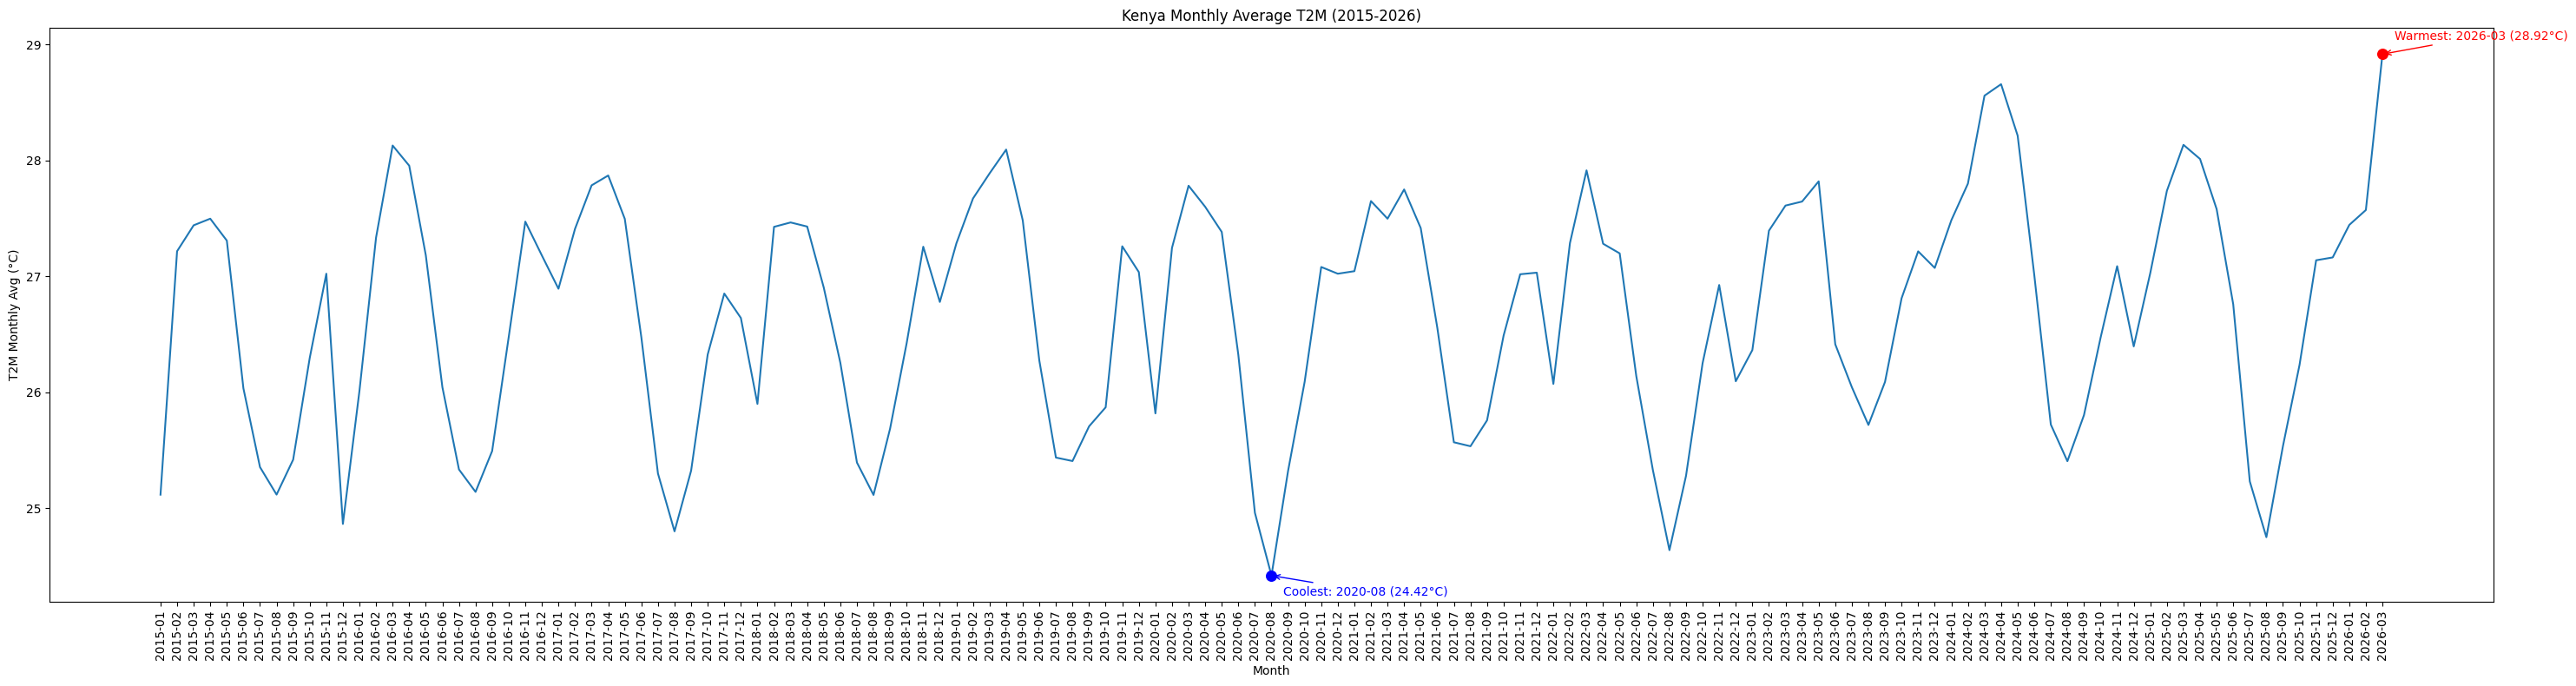

In [22]:
plt.figure(figsize=(30, 8))
x = monthly_t2m["YEAR_MONTH"].astype(str)
y = monthly_t2m["T2M_MONTHLY_AVG"]

plt.plot(x, y)

plt.scatter(x.iloc[warm_idx], y.iloc[warm_idx], color="red", s=70, zorder=5)
plt.scatter(x.iloc[cool_idx], y.iloc[cool_idx], color="blue", s=70, zorder=5)

# annotate warmest
plt.annotate(
    f"Warmest: {x.iloc[warm_idx]} ({y.iloc[warm_idx]:.2f}°C)",
    xy=(x.iloc[warm_idx], y.iloc[warm_idx]),
    xytext=(10, 12),
    textcoords="offset points",
    color="red",
    arrowprops=dict(arrowstyle="->", color="red")
)

# annotate coolest
plt.annotate(
    f"Coolest: {x.iloc[cool_idx]} ({y.iloc[cool_idx]:.2f}°C)",
    xy=(x.iloc[cool_idx], y.iloc[cool_idx]),
    xytext=(10, -16),
    textcoords="offset points",
    color="blue",
    arrowprops=dict(arrowstyle="->", color="blue")
)

plt.title("Kenya Monthly Average T2M (2015-2026)")
plt.xlabel("Month")
plt.ylabel("T2M Monthly Avg (°C)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### Plot monthly total PRECTOTCORR as a bar chart. 

In [23]:
monthly_prectotcorr = (
    df.groupby("YEAR_MONTH", as_index=False)["PRECTOTCORR"]
    .mean()
    .rename(columns={"PRECTOTCORR": "PRECTOTCORR_MONTHLY_AVG"}))

In [24]:
monthly_prectotcorr.head()

,YEAR_MONTH,PRECTOTCORR_MONTHLY_AVG
0,2015-01,0.057742
1,2015-02,1.349643
2,2015-03,4.519839
3,2015-04,2.402667
4,2015-05,3.702097


In [25]:
peak_rain_idx = monthly_prectotcorr["PRECTOTCORR_MONTHLY_AVG"].idxmax()

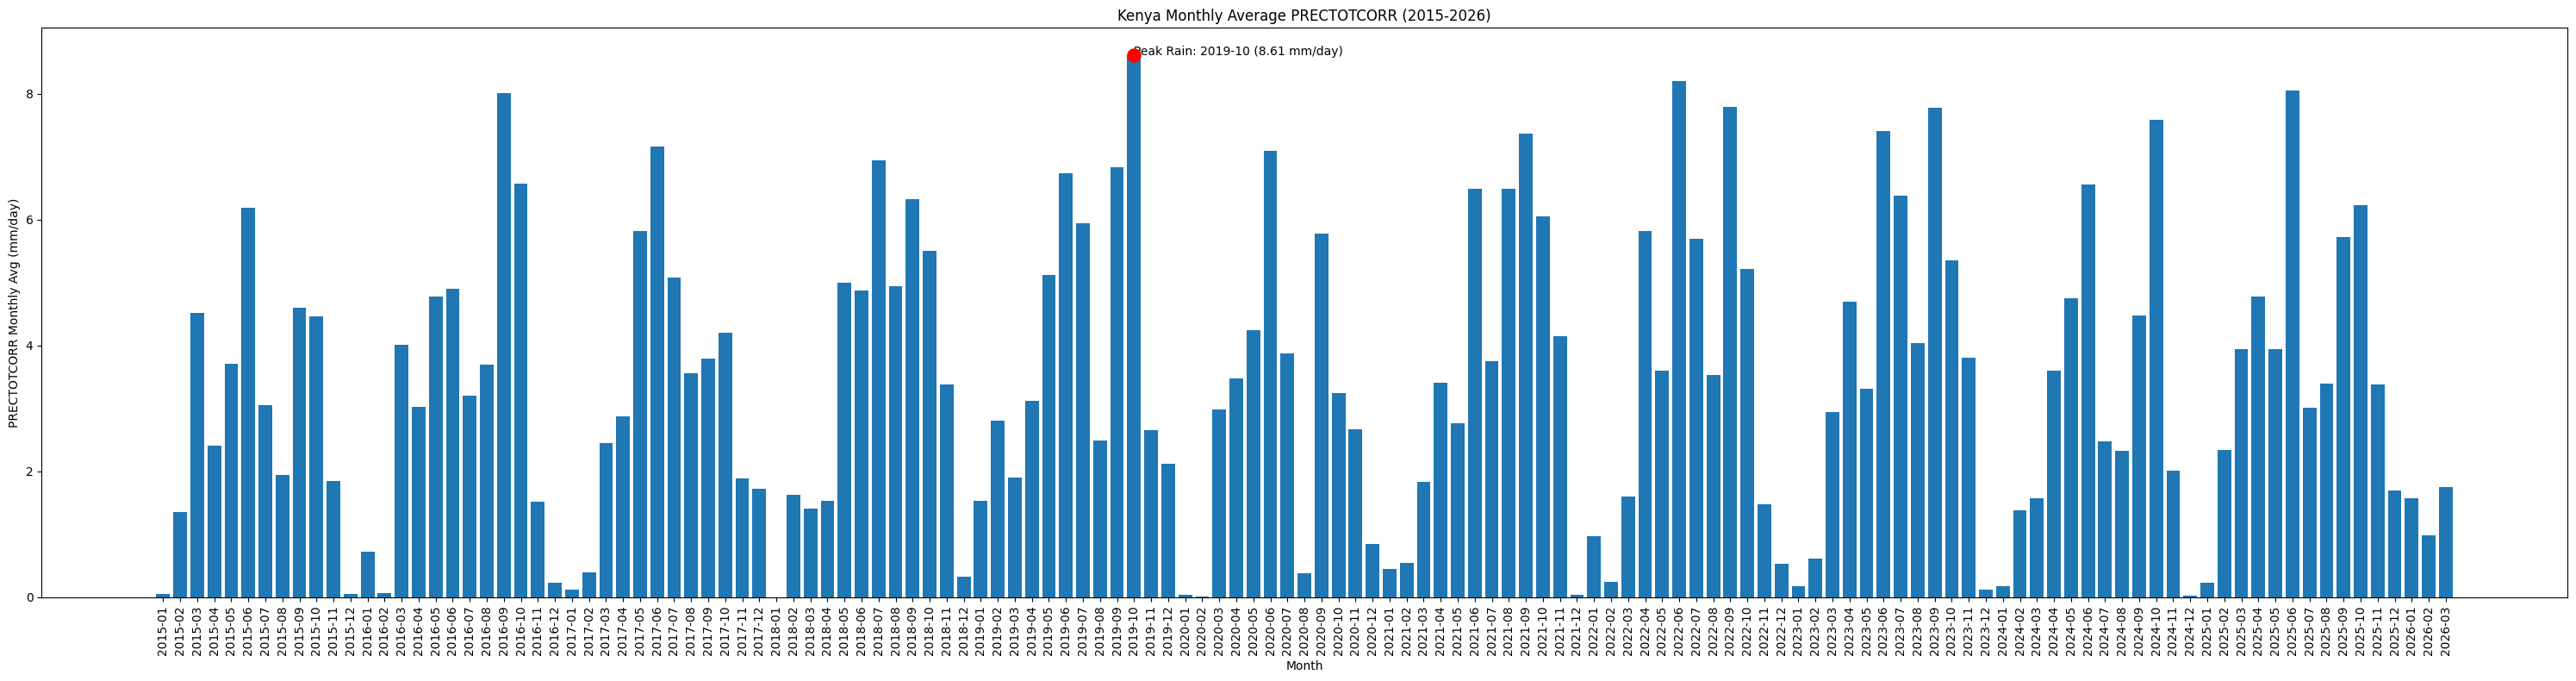

In [26]:
plt.figure(figsize=(30, 8))

plt.bar(
    monthly_prectotcorr["YEAR_MONTH"]
    .astype(str), monthly_prectotcorr["PRECTOTCORR_MONTHLY_AVG"]
    )

plt.scatter(
    monthly_prectotcorr["YEAR_MONTH"].astype(str).iloc[peak_rain_idx], 
    monthly_prectotcorr["PRECTOTCORR_MONTHLY_AVG"].iloc[peak_rain_idx], 
    color="red", s=120, zorder=5
)
plt. annotate(
    f"Peak Rain: {monthly_prectotcorr['YEAR_MONTH'].astype(str).iloc[peak_rain_idx]} ({monthly_prectotcorr['PRECTOTCORR_MONTHLY_AVG'].iloc[peak_rain_idx]:.2f} mm/day)",
    xy=(monthly_prectotcorr["YEAR_MONTH"].astype(str).iloc[peak_rain_idx], monthly_prectotcorr["PRECTOTCORR_MONTHLY_AVG"].iloc[peak_rain_idx]),
    )
plt.title("Kenya Monthly Average PRECTOTCORR (2015-2026)")
plt.xlabel("Month")
plt.ylabel("PRECTOTCORR Monthly Avg (mm/day)")
plt.xticks(rotation=90)
plt.tight_layout()

`The temperature fluctuation trend of the year seems to repeat itself year after year.`

`Months with high or low precipitation are uniform among years`

### Correlation & Relationship Analysis

##### Heatmap of correlations across all numeric columns

<Axes: >

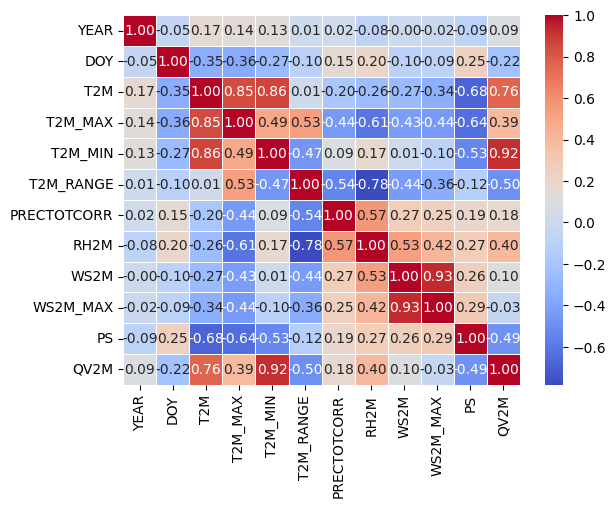

In [27]:
num_df = df.select_dtypes(include=[np.number])

corr = num_df.corr()

# heatmap of correlation matrix
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

`The three strongest correlation:`
`T2M_MIN and QV2M == 0.92`
`T2M and T2M_MAX == 0.86`
`T2M_MAX and T2M == 0.85`


##### Scatter plots: T2M vs. RH2M; T2M_RANGE vs. WS2M

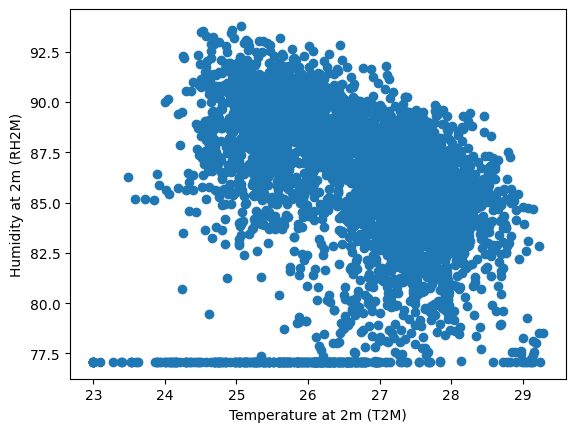

In [28]:
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature at 2m (T2M)")
plt.ylabel("Humidity at 2m (RH2M)");

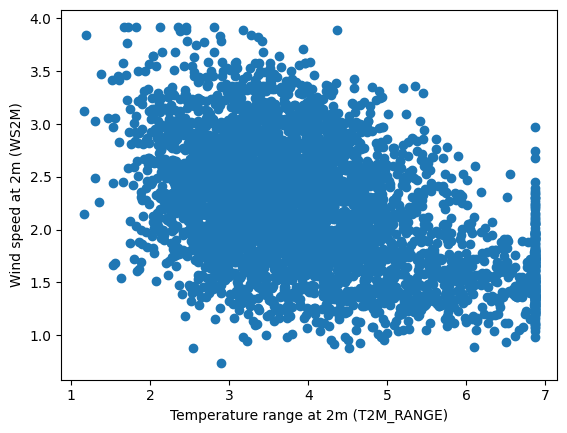

In [29]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temperature range at 2m (T2M_RANGE)")
plt.ylabel("Wind speed at 2m (WS2M)");  

### Distribution Analysis

##### Histogram of PRECTOTCORR

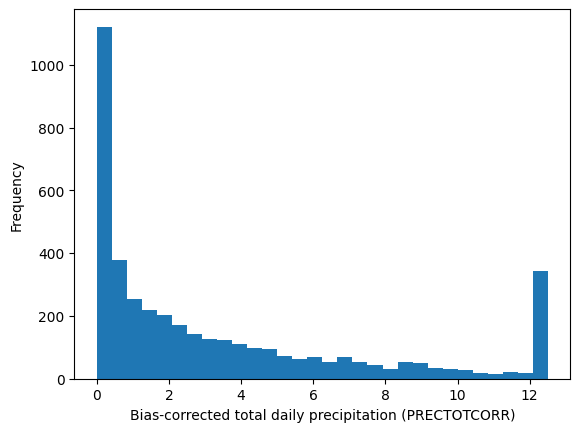

In [30]:
plt.hist(df["PRECTOTCORR"], bins=30)
plt.xlabel("Bias-corrected total daily precipitation (PRECTOTCORR)")
plt.ylabel("Frequency");

##### Applying log scaling since it's heavily skewed

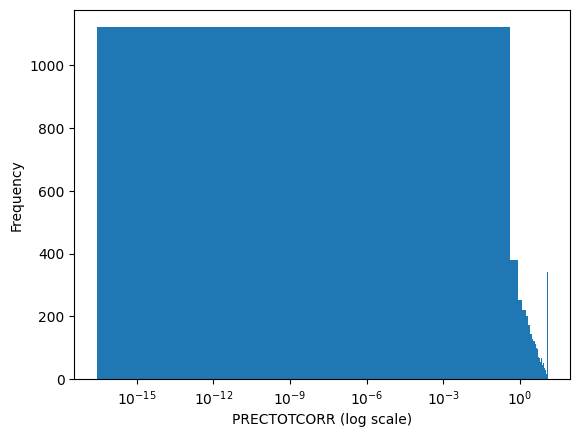

In [31]:
plt.hist(df["PRECTOTCORR"], bins=30)
plt.xscale("log")
plt.xlabel("PRECTOTCORR (log scale)")
plt.ylabel("Frequency");

##### Bubble chart: T2M vs. RH2M, bubble size = PRECTOTCORR.

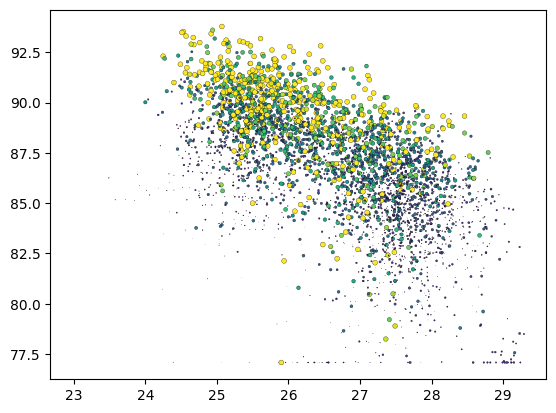

In [32]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"],
    c=df["PRECTOTCORR"],   # optional: color by same variable
    cmap="viridis",
    edgecolors="k",
    linewidths=0.2
)